In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
rounds =10
local_epochs = 1 # This has set to be 1 in the SFLG
users =10  # Number of clients 50,

lr = 0.001

group_client_ordered = True # True means clients are grouped in order -- False means random selection
no_of_groups = 1  # no. of groups/models in the process --- each group has several clients train sequentially at the server


In [ ]:
import os
import h5py

import struct
import pickle
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import time
from tqdm import tqdm
import numpy as np

import pandas
from pandas import DataFrame

from collections import defaultdict
import copy

In [ ]:
# change the yourfolder directory to your own path.
root_path = '/content/drive/MyDrive/Dataset_Quantum'
model_path = '/content/drive/MyDrive/Dataset_Quantum/SplitFedComb_IID_model_%dusers_%dcopy.pth'%(users, no_of_groups)
acc_path = '/content/drive/MyDrive/Dataset_Quantum/SplitFedComb_IID_acc_%dusers_%dcopy.hdf5'%(users, no_of_groups)

server_model_path = '/content/drive/MyDrive/Dataset_Quantum/SplitFedComb_IID_%dusers_%dcopy.pth'%(users, no_of_groups)
client_model_path = '/content/drive/MyDrive/Dataset_Quantum/SplitFedComb_IID__%dusers_%dcopy.pth'%(users, no_of_groups)


In [ ]:
#This section imports the data as a dataframe

file_path = '/content/drive/MyDrive/Dataset_Quantum/Cleaned_EdgeIoT.csv' #Data file from drive folder

df = pandas.read_csv(file_path)
df = df.drop('Unnamed: 0',axis=1)

In [ ]:
df['Attack_label'].unique()

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.model_selection import train_test_split

## Cuda

In [ ]:
device = torch.device("cuda:0")
print(device)


In [ ]:
class Model():

    def __init__(self, train=True, choose = -1):
      n_features = 8
      df = pandas.read_csv(file_path)
      df = df.drop('Unnamed: 0',axis=1)
      Features = ['mqtt.hdrflags', 'mqtt.msgtype', 'mqtt.len', 'tcp.seq', 'tcp.dstport', 'mqtt.conflags', 'mqtt.ver', 'mqtt.proto_len', 'mqtt.conflag.cleansess', 'mqtt.protoname', 'amqtt.protoname', 'mqtt.topic_len', 'tcp.flags.ack', 'tcp.flags', 'tcp.ack_raw', 'tcp.checksum', 'icmp.seq_le', 'icmp.checksum', 'udp.stream', 'tcp.connection.syn', 'tcp.srcport', 'http.response', 'tcp.ack', 'tcp.connection.fin', 'tcp.len']
      X = df[Features[:n_features]]
      y = df['Attack_label']
      X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.33)
      if train:
        if choose == -1:
            self.x  = X_train
            self.y = Y_train
        else:
          num_dataset = int( 157404 / users) #157404   500
          classlist = list(range(num_dataset*choose, num_dataset * (choose+1)))

          self.x = X[num_dataset*choose:num_dataset * (choose+1)]

          self.y = y[(num_dataset*choose):(num_dataset * (choose+1))]
      else:
        self.x = X_test
        self.y = Y_test

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return torch.tensor(self.x.iloc[idx], dtype=torch.float), torch.tensor(self.y.iloc[idx])

## Making Batch Generator

In [ ]:
batch_size = 32

In [ ]:


train_datasets = []

for i in range(users):
  dataset = Model(train=True, choose=i)
  train_datasets.append(dataset)
  print("Train Dataset(x_train) Shape: ", train_datasets[i].x.shape)
train_dataset = Model(train=True)
test_dataset = Model(train=False)
print("Train Dataset(x_train) Shape: ", train_datasets[i].x.shape)
print("Test Dataset(x_test) Shape: ", test_dataset.x.shape)

In [ ]:

train_loaders = []
for i in range(users):
  train_loaders.append(DataLoader(train_datasets[i], batch_size=batch_size))
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [ ]:

train_load = DataLoader(train_datasets[0], batch_size=32)

train_features, train_labels = next(iter(train_load))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

In [ ]:
group_client_collect_dict = defaultdict(list)
# ordered division of clients in the group: group1 -- client0 to clientx
if group_client_ordered:
    #initialize
    start = 0
    step = int(users/no_of_groups)

    diff = users - step* no_of_groups
    #print(diff)

    if diff != 0:
        end = step + 1
        diff -= 1
    else:
        end = step

    for n in range(no_of_groups):

        clients_list = [i for i in range(start, end)]
        group_client_collect_dict[n]= clients_list

        #print("Start, end:",start, end)

        if end+step <= users:
            start = copy.deepcopy(end)
            if diff != 0:
                end += step + 1
                diff -= 1
            else:
                end += step

        else:
            start = copy.deepcopy(end)
            end = users

else:
    print("program is currently in group_client_ordered mode!")




print(group_client_collect_dict)

### Number of total batches

In [ ]:
train_total_batch = len(train_loaders[0])
print(train_total_batch)
test_batch = len(test_loader)
print(test_batch)

In [ ]:
# Dataset size for the serverside -- group wise averaging

datasetsize_server = []
len_dataset = 0
for g in range(no_of_groups):
    for idx in group_client_collect_dict[g]:
        len_dataset += len(train_datasets[idx])
    datasetsize_server.append(len_dataset)
    len_dataset = 0


# Dataset size for the client-size -- client wise averaging
datasetsize_client = []
for i in range(users):
  datasetsize_client.append(len(train_datasets[i]))

## Construct the quantum classical classification model




In [ ]:
!pip install pennylane
import pennylane as qml


n_qubits = 8
n_layers = 8
weight_shapes = {"quantum_weights": (n_layers, n_qubits, 3)}
dev = qml.device("default.qubit", wires=n_qubits)


@qml.qnode(dev, interface="torch")
def qcircuit(inputs,quantum_weights):
    global n_qubits, n_layers

    qml.AngleEmbedding(features=inputs, wires=range(n_qubits))

    # Apply BasicEntanglerLayers
    qml.StronglyEntanglingLayers(weights=quantum_weights, wires=range(n_qubits))


    return [qml.expval(qml.PauliX(i)) for i in range(n_qubits)]


###Models

In [ ]:
class ModelNet(nn.Module):
    def __init__(self):
        super(ModelNet, self).__init__()  # necessary for nn.Module
        global n_qubits, n_layers , weight_shapes
        self.n_features = 8
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.weights = weight_shapes

        self.linear1 = nn.Linear(8, 128)
        self.relu1 = nn.LeakyReLU()
        self.linear2 = nn.Linear(128, 8)
        self.relu2 = nn.LeakyReLU()

        self.qlayer = qml.qnn.TorchLayer(qcircuit,  weight_shapes = self.weights).requires_grad_(True)

        self.linear3 = nn.Linear(n_qubits, 1)  # Output size should be 1 for binary classification
        self.sigmoid = nn.Sigmoid()  # Use Sigmoid for binary classification

    def forward(self, x):
        x = x.view(x.size(0), -1)
        # Pass through classical layers
        x = self.linear1(x)
        x = self.relu1(x)
        x = self.linear2(x)
        x = self.relu2(x)

        # Pass through quantum layer
        x = self.qlayer(x)  # slice inputs to match n_qubits

        # Pass through final classical layer
        x = self.linear3(x)
        x = self.sigmoid(x)  # Apply Sigmoid to get a probability between 0 and 1
        return x


In [ ]:
model_net = ModelNet()


In [ ]:
class ModelClient(nn.Module):
    def __init__(self):
        super(ModelClient, self).__init__()
        global n_qubits, n_layers , weight_shapes
        self.n_features = 8
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.weights = weight_shapes

        self.linear1 = nn.Linear(8, 128)
        self.relu1 = nn.LeakyReLU()
        self.linear2 = nn.Linear(128, 8)
        self.relu2 = nn.LeakyReLU()

        #self.qlayer = qml.nn.TorchLayer(qcircuit, nn.Parameter(torch.randn(n_layers, n_qubits,3))).requires_grad_(True)

        #self.linear3 = nn.Linear(n_qubits, 1)  # Output size should be 1 for binary classification
        #self.sigmoid = nn.Sigmoid()  # Use Sigmoid for binary classification

    def forward(self, x):
        x = x.view(x.size(0), -1)
        # Pass through classical layers
        x = self.linear1(x)
        x = self.relu1(x)
        x = self.linear2(x)
        x = self.relu2(x)

        # Pass through quantum layer
        #x = self.qlayer(x)  # slice inputs to match n_qubits

        # Pass through final classical layer
        #x = self.linear3(x)
        #x = self.sigmoid(x)  # Apply Sigmoid to get a probability between 0 and 1
        return x

In [ ]:
model_client = ModelClient()


In [ ]:
class ModelServer(nn.Module):
    def __init__(self):
        super(ModelServer, self).__init__()
        global n_qubits, n_layers, weight_shapes
        self.n_features = 8
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.weights = weight_shapes
        #self.linear1 = nn.Linear(8, 128)
        #self.relu1 = nn.LeakyReLU()
        #self.linear2 = nn.Linear(128, 8)
        #self.relu2 = nn.LeakyReLU()

        self.qlayer = qml.qnn.TorchLayer(qcircuit, weight_shapes = self.weights).requires_grad_(True)
        self.linear3 = nn.Linear(n_qubits, 1)  # Output size should be 1 for binary classification
        self.sigmoid = nn.Sigmoid()  # Use Sigmoid for binary classification

    def forward(self, x):
        #x = x.view(x.size(0), -1)
        # Pass through classical layers
        #x = self.linear1(x)
        #x = self.relu1(x)
        #x = self.linear2(x)
        #x = self.relu2(x)

        # Pass through quantum layer
        x = self.qlayer(x)  # slice inputs to match n_qubits

        # Pass through final classical layer
        x = self.linear3(x)
        x = self.sigmoid(x)  # Apply Sigmoid to get a probability between 0 and 1
        return x

In [ ]:
model_server = ModelServer()


## variables

In [ ]:
clientsoclist = []
train_total_batch = []

criterion = nn.BCELoss()
train_acc = []
val_acc = []
train_lo = []
val_lo = []
train_acc_average=[]

optimizer = Adam(model_net.parameters(), lr=lr)
optimizer_client = Adam(model_client.parameters(), lr=lr)
optimizer_server = Adam(model_server.parameters(), lr=lr)

weights_server_list_group = []
weights_client_list_group = []

## Comunication overhead

In [ ]:
total_sendsize_list = []
total_receivesize_list = []

client_sendsize_list = [[] for i in range(users)]
client_receivesize_list = [[] for i in range(users)]

train_sendsize_list = []
train_receivesize_list = []

In [ ]:
import copy

def average_weights(w, datasize):
    """
    Returns the average of the weights.
    """

    for i, data in enumerate(datasize):
        for key in w[i].keys():
            w[i][key] *= float(data)

    w_avg = copy.deepcopy(w[0])

    for key in w_avg.keys():
        for i in range(1, len(w)):
            w_avg[key] += w[i][key]
        w_avg[key] = torch.div(w_avg[key], float(sum(datasize)))


    return w_avg

In [ ]:
start_time = time.time()    # store start time
print("timmer start!")
# train()

In [ ]:
def train_client(inputs, labels):


    # zero the parameter gradients
    optimizer_client.zero_grad()

    # forward + backward + optimize
    #----------- Running client side -----------
    outputs = model_client(inputs)
    client_output = outputs.clone().detach().requires_grad_(True)

    #------------Running server side ------------
    client_grad = train_server(client_output, labels)
    outputs.backward(client_grad)
    optimizer_client.step()


In [ ]:
def train_server(client_output, labels):
    optimizer_server.zero_grad()
    output = model_server(client_output)
    loss = criterion(output, labels)
    loss.backward()
    optimizer_server.step()

    return client_output.grad.clone().detach()

## Train

In [ ]:
group_client_weights_collect = []

# global weights at first
global_client_weights = copy.deepcopy(model_client.state_dict())
global_server_weights = copy.deepcopy(model_server.state_dict())
for r in range(rounds):
    # initialize the weights of the model for this round
    round_client_weights = copy.deepcopy(global_client_weights)

    round_server_weights = copy.deepcopy(global_server_weights)
    # we will run by groups ----
    for g in range(no_of_groups):
        # for each user in the group g
        #group_client_weights = copy.deepcopy(round_client_weights)
        group_server_weights = copy.deepcopy(round_server_weights)

        for u in group_client_collect_dict[g]:
            # model for user u
            #print("User:", u)

            # client has the same initial state for the group
            model_client.load_state_dict(round_client_weights)

            # server model state changes with clients
            model_server.load_state_dict(group_server_weights)


            for local_epoch in range(local_epochs):

                for data in tqdm(train_loaders[u], ncols=100, desc='Round'+str(r+1)+': User'+str(u)+'_'+str(local_epoch+1)):

                    # get the inputs; data is a list of [inputs, labels]
                    inputs, labels = data
                    inputs = inputs

                    labels = labels.clone().detach().type(torch.float)

                    #------------ client forward training -----------
                    optimizer_client.zero_grad()
                    client_output = model_client(inputs)

                    #------------ server forward training -----------
                    optimizer_server.zero_grad()
                    server_input = client_output.clone().detach().requires_grad_(True)
                    server_input  = server_input
                    # ---------- server forward/backward training ------------
                    optimizer_server.zero_grad()
                    server_output = model_server(server_input)
                    labels = labels.unsqueeze(1)
                    loss = criterion(server_output, labels)


                    loss.backward()
                    optimizer_server.step()
                    client_grad = server_input.grad.clone().detach()
                    # ----------- client backward training ------------
                    client_output.backward(client_grad)
                    optimizer_client.step()



                # going for next user in the same group
                client_weights = copy.deepcopy(model_client.state_dict())
                group_client_weights_collect.append(client_weights)

                group_server_weights = copy.deepcopy(model_server.state_dict())



        # Now going for the different group
        # save the weights of the current model -- current group
        weights_server_list_group.append(group_server_weights)


    # Completion for all groups
    # average

    global_client_weights = average_weights(group_client_weights_collect, datasetsize_client)

    global_server_weights = average_weights(weights_server_list_group, datasetsize_server)

    weights_server_list_group = []
    group_client_weights_collect = []


    #==============================================================================================

    #=================================================================================================

    #================================================================================================================
    # Accuracy check at each round (this is for the gloabl model --- not local model) -------------------------------
    # This is s result for the global model at each round --------
    model_client.load_state_dict(global_client_weights)
    model_server.load_state_dict(global_server_weights)
    model_client.eval()
    model_server.eval()





In [ ]:
with torch.no_grad():
  for u in range(users):
      corr_num = 0
      total_num = 0
      train_loss = 0.0
      for j, trn in enumerate(train_loaders[u]):
          trn_x, trn_label = trn
          trn_x = trn_x
          trn_label = trn_label.clone().detach().type(torch.float)

          trn_output = model_client(trn_x)
          trn_output = model_server(trn_output)
          trn_output = trn_output.squeeze(1)
          loss = criterion(trn_output, trn_label)
          train_loss += loss.item()
          model_label = (trn_output >= 0.5).float()
          corr = trn_label[trn_label == model_label].size(0)
          corr_num += corr
          total_num += trn_label.size(0)
      train_accuracy = corr_num / total_num * 100
      r_train_loss = train_loss / len(train_loaders[u])
      print("client {}: rounds {}'s train_acc: {:.2f}%, train_loss: {:.4f}".format(u, r + 1, train_accuracy, r_train_loss))
      train_acc.append(train_accuracy)
  avg_acc = sum(train_acc)/len(train_acc)
  print("Train_average accuracy:", avg_acc)
  train_acc_average.append(avg_acc)
  train_acc = []

predictions =[]
with torch.no_grad():
  corr_num = 0
  total_num = 0
  val_loss = 0.0
  all_preds = []
  all_labels = []

  for j, val in enumerate(test_loader):
      val_x, val_label = val
      val_x = val_x
      val_label = val_label.clone().detach().type(torch.float)

      val_output = model_client(val_x)
      val_output = model_server(val_output)
      val_output = val_output.squeeze(1)
      loss = criterion(val_output, val_label)
      val_loss += loss.item()
      model_label = (val_output  >= 0.5).float()
      predictions.append(model_label)

      corr_num += corr
      total_num += val_label.size(0)
      corr = val_label[val_label == model_label].size(0)

      corr_num += corr
      total_num += val_label.size(0)
      all_preds.extend(model_label.cpu().numpy())  # Store predictions
      all_labels.extend(val_label.cpu().numpy())  # Store true labels
  test_accuracy = corr_num / total_num * 100
  test_loss = val_loss / len(test_loader)
  print("rounds {}'s Validation_acc: {:.2f}%, test_loss: {:.4f}".format(r + 1, test_accuracy, test_loss))
  val_acc.append(test_accuracy)
end_time = time.time()  # store end time
print("TrainingTime: {} sec".format(end_time - start_time))

In [ ]:
  from sklearn import metrics
  Accuracy = metrics.accuracy_score(all_labels,all_preds)
  Sensitivity = metrics.recall_score(all_labels,all_preds)
  Precision = metrics.precision_score(all_labels,all_preds)
  F1_score = metrics.f1_score(all_labels,all_preds)
  Recall = metrics.recall_score(all_labels,all_preds)

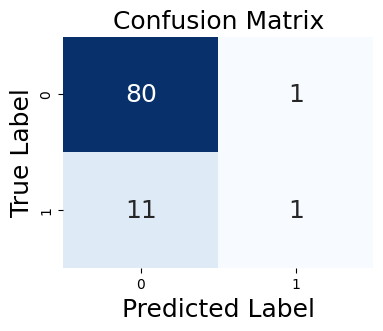

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = [[ 99,1],[99,1]]

# Plot confusion matrix
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 18})

plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix", fontsize=18)
plt.show()

NameError: name 'cm' is not defined

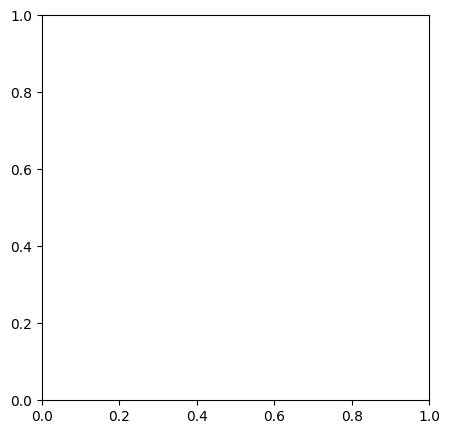

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

conf_matrices = np.stack([
    np.array([[97.20, 2.8], [0.4, 99.6]]),
    np.array([[98.0, 2.0], [0.3, 99.7]]),
    np.array([[98.2, 1.8], [0.2, 99.8]]),
    np.array([[95.8, 4.2], [1.1, 98.9]]),
    np.array([[96.5, 3.5], [0.8, 99.2]]),
    np.array([[97.0, 3.0], [1.5, 98.5]])
])
# Convert to percentages
conf_matrix_percent = conf_matrices

i =0
# Plot confusion matrix
for i, matrix in enumerate(conf_matrix_percent):
    # Format values with percentage symbol
    annot_labels = np.array([[f"{val:.2f}%" for val in row] for row in matrix])

    plt.figure(figsize=(5,5))
    ax= plt.subplot()
    sns.heatmap(matrix,cm, annot=True, fmt='g', ax=ax)
    # labels, title and ticks
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix')
    ax.xaxis.set_ticklabels(['business', 'health'])
    ax.yaxis.set_ticklabels(['health', 'business'])


    #plt.xticks([0.5, 1.5], ["0", "1"], fontsize=32)
    #plt.yticks([0.5, 1.5], ["0", "1"], fontsize=32)
    #plt.xlabel("Predicted Label", fontsize=32)
    #plt.ylabel("True Label", fontsize=32)
    #plt.legend
    #plt.savefig(f'confusion_matrix{i}.pdf')
    plt.show()